Objectives of this notebook :

- Import librairies
- Load raw data
- Do a pre-treatment to generate a unique merged dataset
- Explore our data (distributions and correlations)
- Conclusion : decisions for our pipeline

In [66]:
#Librairies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns



## Load raw data 

In [42]:
#Load datasets
circuits = pd.read_csv("./data/raw/circuits.csv")
constructor_results = pd.read_csv("./data/raw/constructor_results.csv")
constructor_standings = pd.read_csv("./data/raw/constructor_standings.csv")
constructors = pd.read_csv("./data/raw/constructors.csv")
driver_standings = pd.read_csv("./data/raw/driver_standings.csv")
drivers = pd.read_csv("./data/raw/drivers.csv")
lap_times = pd.read_csv("./data/raw/lap_times.csv")
pit_stops = pd.read_csv("./data/raw/pit_stops.csv")
qualifying = pd.read_csv("./data/raw/qualifying.csv")
races = pd.read_csv("./data/raw/races.csv")
results = pd.read_csv("./data/raw/results.csv")
seasons = pd.read_csv("./data/raw/seasons.csv")
sprint_results = pd.read_csv("./data/raw/sprint_results.csv")
status = pd.read_csv("./data/raw/status.csv")

datasets = {
    "circuits": circuits,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "constructors": constructors,
    "driver_standings": driver_standings,
    "drivers": drivers,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Optionnel : afficher les 3 premières lignes de chaque fichier
for name, df in datasets.items():
    print(f"\n=== {name} ===")
    display(df.head(3))



circuits: 77 lignes, 9 colonnes
constructor_results: 12625 lignes, 5 colonnes
constructor_standings: 13391 lignes, 7 colonnes
constructors: 212 lignes, 5 colonnes
driver_standings: 34863 lignes, 7 colonnes
drivers: 861 lignes, 9 colonnes
lap_times: 589081 lignes, 6 colonnes
pit_stops: 11371 lignes, 7 colonnes
qualifying: 10494 lignes, 9 colonnes
races: 1125 lignes, 18 colonnes
results: 26759 lignes, 18 colonnes
seasons: 75 lignes, 2 colonnes
sprint_results: 360 lignes, 16 colonnes
status: 139 lignes, 2 colonnes

=== circuits ===


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...



=== constructor_results ===


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N



=== constructor_standings ===


...

,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...



=== sprint_results ===


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1



=== status ===


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident


# Pre-treatment

## Missing values

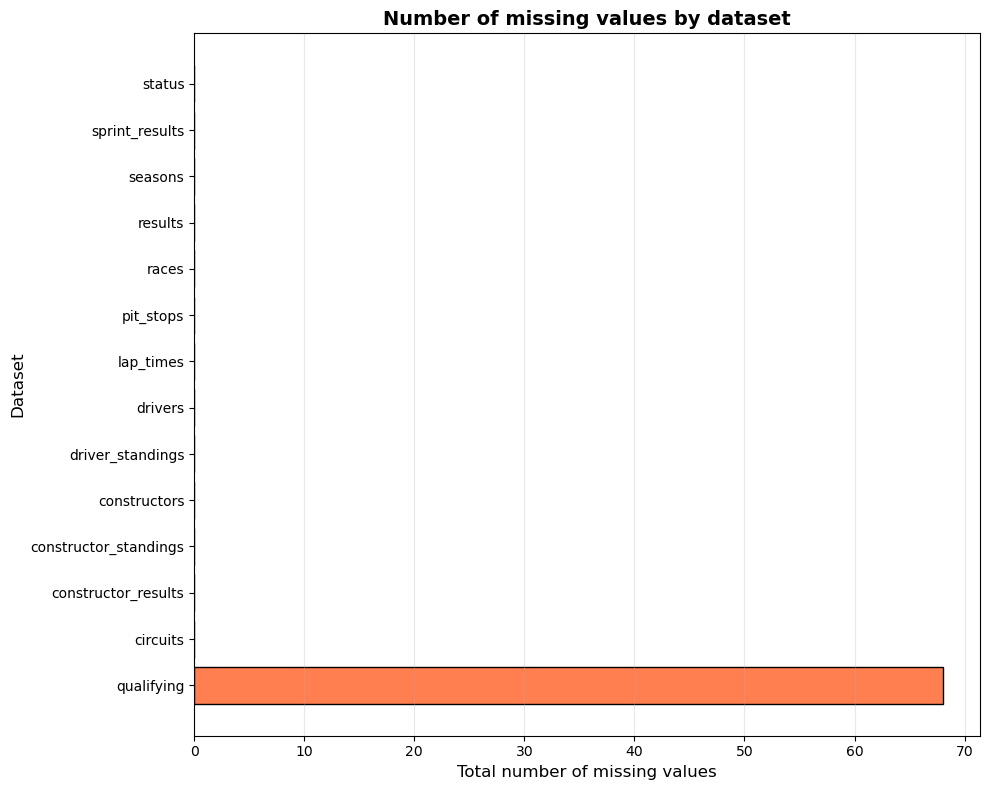

qualifying: 68 missing values (0.07%)
circuits: 0 missing values (0.00%)
constructor_results: 0 missing values (0.00%)
constructor_standings: 0 missing values (0.00%)
constructors: 0 missing values (0.00%)
driver_standings: 0 missing values (0.00%)
drivers: 0 missing values (0.00%)
lap_times: 0 missing values (0.00%)
pit_stops: 0 missing values (0.00%)
races: 0 missing values (0.00%)
results: 0 missing values (0.00%)
seasons: 0 missing values (0.00%)
sprint_results: 0 missing values (0.00%)
status: 0 missing values (0.00%)


In [43]:
missing_counts = {}
for name, df in datasets.items():
    missing_counts[name] = df.isnull().sum().sum()

plt.figure(figsize=(10, 8))
datasets_sorted = dict(sorted(missing_counts.items(), key=lambda x: x[1], reverse=True))
plt.barh(list(datasets_sorted.keys()), list(datasets_sorted.values()), color='coral', edgecolor='black')
plt.xlabel('Total number of missing values', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.title('Number of missing values by dataset', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

for name, count in sorted(missing_counts.items(), key=lambda x: x[1], reverse=True):
    total_cells = datasets[name].shape[0] * datasets[name].shape[1]
    percentage = (count / total_cells) * 100 if total_cells > 0 else 0
    print(f"{name}: {count} missing values ({percentage:.2f}%)")


As we can see, there is very few missing values so we don't have to worry too much about missing values.

## Keeping useful columns only

We will keep only relevant columns and datasets for our subject

"Predicting best lap times for each driver for a fixed circuit and year"

We thought the following datasets were not useful for the subject :

*   constructor_results
*   constructor_standings
*   driver_standings
*   sprint_results
*   status
*   seasons
*   pit_stops
*   qualifying

For the other datasets, we also kept only the columns we thought relevant for our project.

In [44]:
circuits=circuits[['circuitId','circuitRef','location']]
races=races[['raceId','year','circuitId','date']]
drivers=drivers[['driverId','driverRef','nationality']]
constructors=constructors[['constructorId','constructorRef','nationality']]
lap_times=lap_times[['raceId','driverId','lap','milliseconds']]
results=results[['raceId','driverId','constructorId','grid','position','points','laps','statusId']]


We reduced the number of columns from 102 to 19, making analysis easier while keeping key informations.

## Merging datasets


To have a unique dataset we merge the previous selected ones on the different IDs.

In [45]:
merged = lap_times.merge(results, on=['raceId', 'driverId'], how='left')
merged = merged.merge(races, on='raceId', how='left')
merged = merged.merge(circuits, on='circuitId', how='left')
merged = merged.merge(drivers, on='driverId', how='left')
merged = merged.merge(constructors, on='constructorId', how='left', suffixes=('_driver', '_constructor'))
df=merged
print(df.shape)
print(df.info())
#print(df.head())

(589081, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589081 entries, 0 to 589080
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   raceId                   589081 non-null  int64  
 1   driverId                 589081 non-null  int64  
 2   lap                      589081 non-null  int64  
 3   milliseconds             589081 non-null  int64  
 4   constructorId            589081 non-null  int64  
 5   grid                     589081 non-null  int64  
 6   position                 589081 non-null  object 
 7   points                   589081 non-null  float64
 8   laps                     589081 non-null  int64  
 9   statusId                 589081 non-null  int64  
 10  year                     589081 non-null  int64  
 11  circuitId                589081 non-null  int64  
 12  date                     589081 non-null  object 
 13  circuitRef               589081 non-null  obje

We have 11 quantitatives and 8 qualitatives columns.

In [46]:
merged.to_csv('data/processed/merged_data.csv', index=False)

print(f"Données sauvegardées dans data/processed/merged_data.csv")

Données sauvegardées dans data/processed/merged_data.csv


# EDA

## Univariate analysis and statistics

### Drivers

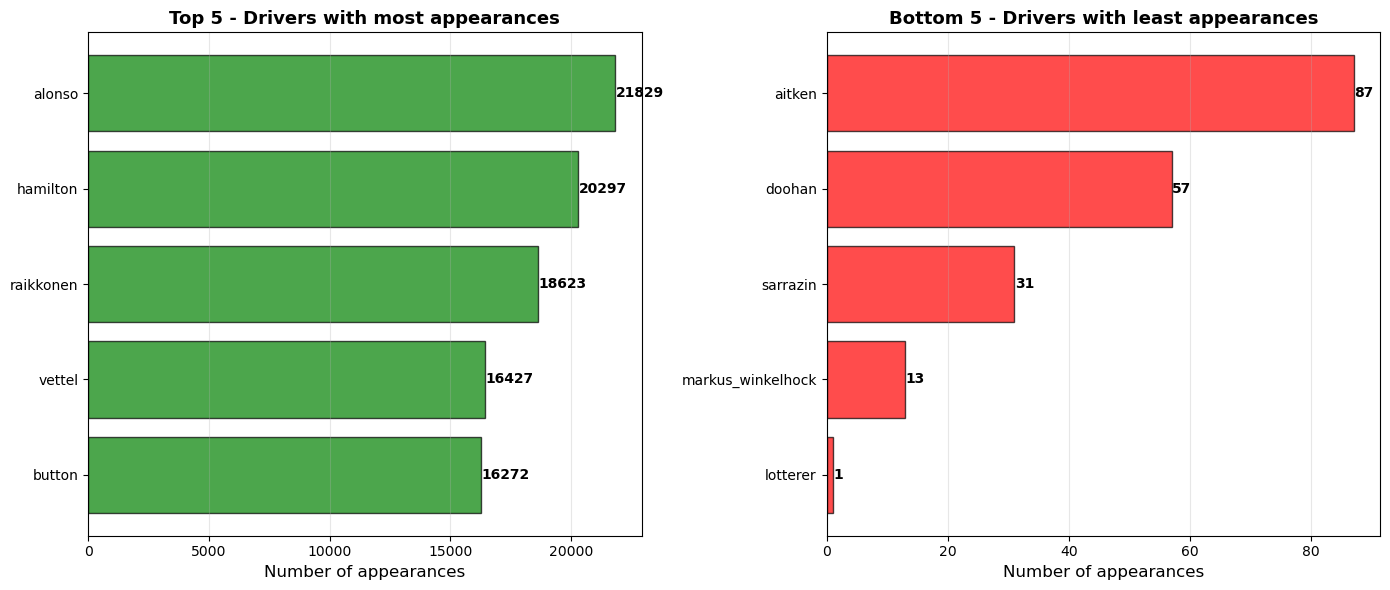

There are 143 different drivers in the dataset.


In [47]:
driver_counts = merged['driverRef'].value_counts()

top_5 = driver_counts.head(5)
bottom_5 = driver_counts.tail(5)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


bars1 = ax1.barh(range(len(top_5)), top_5.values[::-1], color='green', edgecolor='black', alpha=0.7)
ax1.set_yticks(range(len(top_5)))
ax1.set_yticklabels(top_5.index[::-1])
ax1.set_xlabel('Number of appearances', fontsize=12)
ax1.set_title('Top 5 - Drivers with most appearances', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


for i, count in enumerate(top_5.values[::-1]):
    ax1.text(count + 5, i, str(count), ha='left', va='center', fontsize=10, fontweight='bold')

bars2 = ax2.barh(range(len(bottom_5)), bottom_5.values[::-1], color='red', edgecolor='black', alpha=0.7)
ax2.set_yticks(range(len(bottom_5)))
ax2.set_yticklabels(bottom_5.index[::-1])
ax2.set_xlabel('Number of appearances', fontsize=12)
ax2.set_title('Bottom 5 - Drivers with least appearances', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)


for i, count in enumerate(bottom_5.values[::-1]):
    ax2.text(count + 0.05, i, str(count), ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"There are {driver_counts.count()} different drivers in the dataset.")




In our dataset you can find 143 different drivers. We ranked them by the number of laps they did. Fun fact Lotterer only did one lap in his entire career because he had a problem and couln't finish his first ever lap. He surprisingly stop F1 after this incident. https://en.wikipedia.org/wiki/Andr%C3%A9_Lotterer

### Races

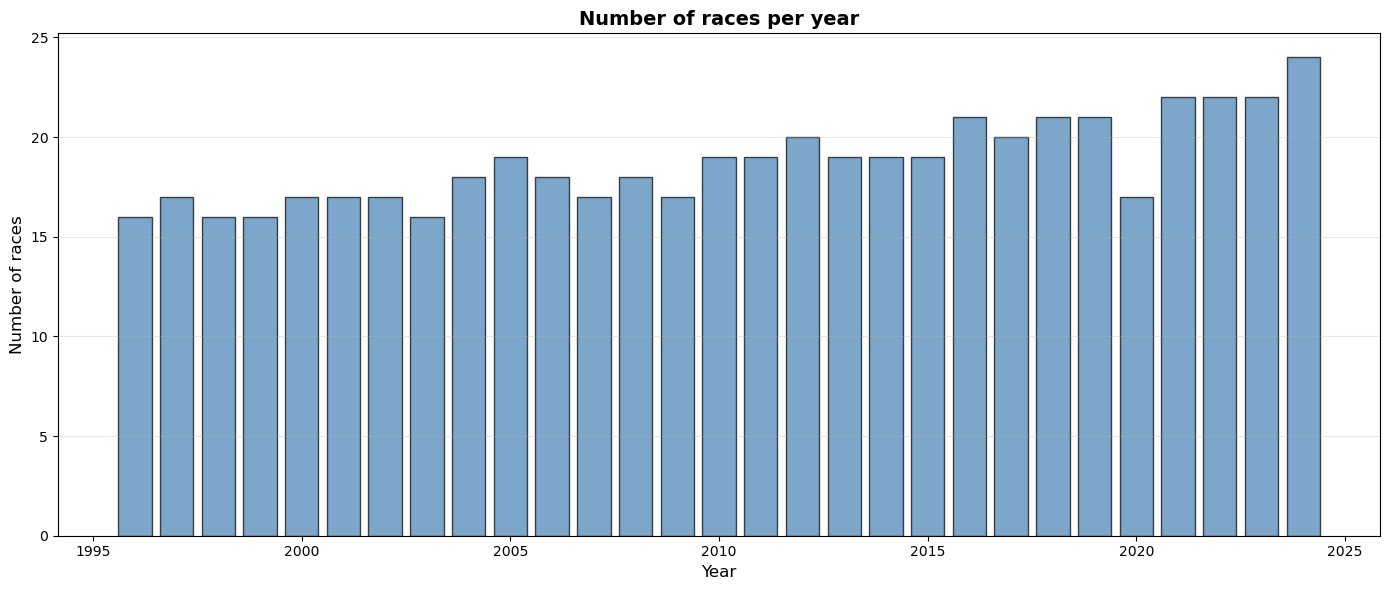

There are 544 different races.


In [48]:
races_per_year = merged.groupby('year')['raceId'].nunique().reset_index(name='nb_races')


plt.figure(figsize=(14, 6))
plt.bar(races_per_year['year'], races_per_year['nb_races'], color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of races', fontsize=12)
plt.title('Number of races per year', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"There are 544 different races.")

544 different courses since 1996. We can see that at first there was 16 races by year and with time, they changed some circuits. Globally, the number of circuits per year increased and nowadays there is 24 races by year.

### Circuits

In [64]:
nb_circuits = merged['circuitId'].nunique()
print(f"There are {nb_circuits} different circuits in the dataset.")
courses_par_circuit = (
    df[['raceId', 'circuitId']]
    .drop_duplicates()
    .groupby('circuitId')
    .size()
    .reset_index(name='nb_courses')
    .sort_values(by='nb_courses', ascending=False)
)
courses_par_circuit = courses_par_circuit.merge(circuits, on='circuitId', how='left')
print("\n Top 3 circuits with most races")
courses_par_circuit[['circuitRef', 'nb_courses']].head(3)


There are 41 different circuits in the dataset.

 Top 3 circuits with most races


,circuitRef,nb_courses
0,silverstone,30
1,catalunya,29
2,hungaroring,29


In [65]:
print("\n Top 3 circuits with less races")
courses_par_circuit[['circuitRef', 'nb_courses']].tail(3)


 Top 3 circuits with less races


,circuitRef,nb_courses
38,jerez,1
39,estoril,1
40,mugello,1


41 differents circuits since 1996. The only circuit that is here since 1996 is Silverstone. Some other circuits are quite old too but there is also some that were run once. We have to know that depending on the circuit we will have more or less informations.

### Constructors

In [ ]:
constructor_counts = merged.groupby('constructorRef')['raceId'].nunique().reset_index(name='number_of_races')
constructor_counts = constructor_counts.merge(
    merged[['constructorRef', 'nationality_constructor']].drop_duplicates(),
    on='constructorRef',
    how='left'
)
constructor_counts = constructor_counts.sort_values(by='number_of_races', ascending=False)
constructor_counts.head(10)

,constructorRef,number_of_races,nationality_constructor
10,ferrari,543,Italian
42,williams,543,British
24,mclaren,542,British
31,red_bull,392,Austrian
33,sauber,365,Swiss
25,mercedes,304,German
32,renault,277,French
38,toro_rosso,267,Italian
12,force_india,212,Indian
14,haas,189,American


We can see that over the 544 races of our dataset, some constructors like Ferrari participated to almost all races over the past 20 years.

### Lap & Laps

Column "lap" is the column corresponding to number of the lap the driver currently is. Example : lap 4 of the course for a given driver and race. For more clarity, we will rename it "current_lap".

Now we create our target variable "fastest_lap_time" which is the faster lap time for a given pilot, circuit and year (so given pilot and race).

In [53]:
merged = merged.rename(columns={'lap': 'current_lap'})
print(merged['current_lap'].describe())

count    589081.000000
mean         30.018104
std          18.407126
min           1.000000
25%          14.000000
50%          29.000000
75%          44.000000
max          87.000000
Name: current_lap, dtype: float64


Almost the same as 'lap', 'laps' is the total number of laps completed at the end of a race by a driver. As we said in the Lap section, some drivers do not finish the race so this can differ between drivers on a same race. We will also rename it in "total_laps"

In [54]:
merged= merged.rename(columns={'laps': 'total_laps'})
print(merged['total_laps'].describe())

count    589081.000000
mean         59.021839
std          12.095074
min           0.000000
25%          53.000000
50%          58.000000
75%          69.000000
max          87.000000
Name: total_laps, dtype: float64


We can see that the mean number of lap completed in a race is 59. This variable ranges from 0 to 87 laps (Monaco). If a driver is out, the remaining laps are not in our dataset so for a same race, the number of laps may differ depending on the driver. This explain why the minimum total number of laps is 0, maybe a driver had a problem with the car before the race and couldn't start.

### Milliseconds & creation of Target Variable

This is the variable we will use to create our target variable. We will convert rename it in 'lap_time' and convert it in seconds to make it easier to read.


In [50]:
merged["lap_seconds"] = merged["milliseconds"] / 1000
merged = merged.drop(columns=['milliseconds'])

In [51]:
print(merged['lap_seconds'].describe())

count    589081.000000
mean         95.799445
std          76.399730
min          55.404000
25%          82.041000
50%          90.608000
75%         101.930000
max        7507.547000
Name: lap_seconds, dtype: float64


We can see that the mean time for a lap is approximately 95.8s but the standard deviation is quite high (76.4s). This is normal because these statistics are done for all circuits and years mixed and we know that all circuits have different lengths.

Now we create our target variable "fastest_lap_time" which is the faster lap time for a given pilot, circuit and year (so given pilot and race).

In [52]:
merged['fastest_lap_time'] = (merged.groupby(['raceId', 'driverId'])['lap_seconds'].transform('min'))

### Evolution of fastest lap time over year

We wanted to see how the speed of cars in F1 evolved over time. For this, we had to study the global best lap time (all driver) for a specified circuit. We first did it with Silverstone circuit because it's the oldest in our dataset but the layout of this circuit changed a lot in 30 years so the results were not very interesting. We chose Albert Park circuit because he is old and didn't change in the last few years.

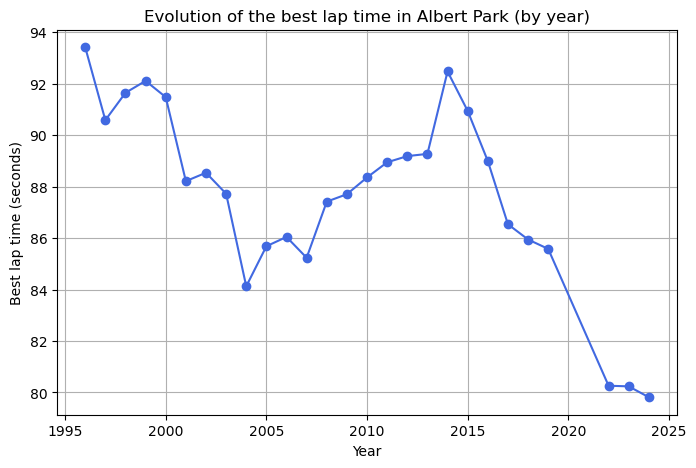

In [63]:
albert_park = merged[merged['circuitRef'].str.contains("albert_park", case=False, na=False)]


evolution = (
    albert_park.groupby('year')['fastest_lap_time']
    .min()
    .reset_index()
    .sort_values('year')
)
plt.figure(figsize=(8,5))
plt.plot(evolution['year'], evolution['fastest_lap_time'], marker='o', linestyle='-', color='royalblue')
plt.title("Evolution of the best lap time in Albert Park (by year)")
plt.xlabel("Year")
plt.ylabel("Best lap time (seconds)")
plt.grid(True)
plt.show()

On this diagramm, we can see that the best lap time globally decreased since 1995. Independently of the layout changes and the weather that can affect the lap times, we can see that cars are getting faster and faster and we have to adapt our model to these technological changes.

We looked online and saw that one major change in F1 field is the introduction of hybrid V6 turbo engines in 2014.
These engines are far more powerful than the precedents and new rules were also added that year. We can see it on this graph and we wanted to see if this change was also visible on other circuit :

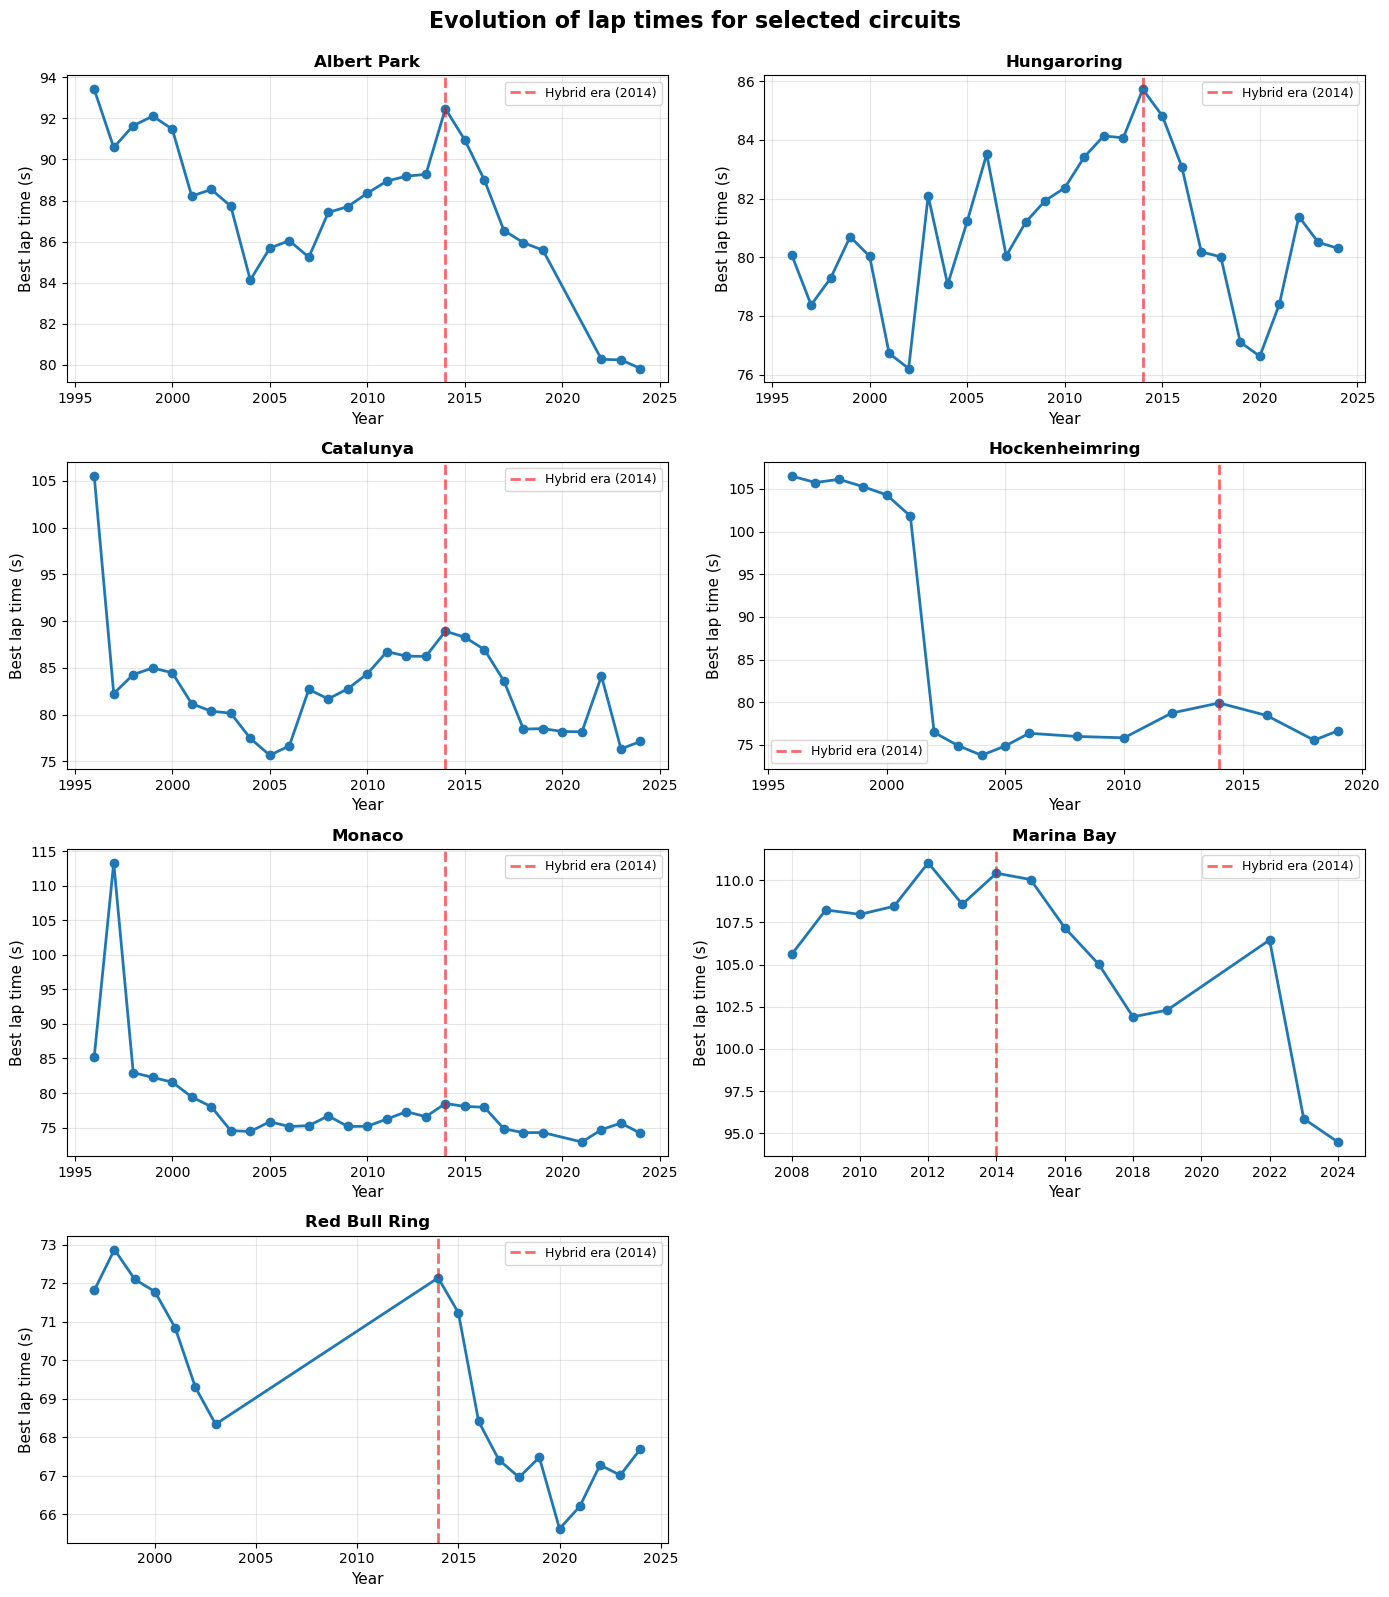

In [ ]:
selected_circuits = ['albert_park', 'hungaroring', 'catalunya', 'hockenheimring', 
                    'monaco', 'marina_bay', 'red_bull_ring']


fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, circuit in enumerate(selected_circuits):
    circuit_data = merged[merged['circuitRef'] == circuit].copy()
    evolution = circuit_data.groupby('year')['fastest_lap_time'].min().reset_index()
    
    ax = axes[idx]
    ax.plot(evolution['year'], evolution['fastest_lap_time'], marker='o', linewidth=2, markersize=6)
    ax.set_title(f"{circuit.replace('_', ' ').title()}", fontweight='bold', fontsize=12)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Best lap time (s)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=2014, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Hybrid era (2014)')
    ax.legend(fontsize=9)

axes[-1].axis('off')

plt.suptitle('Evolution of lap times for selected circuits', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

We can see that this change is visible on other circuits so this not an isolated phenomena. 
Other major changes occured since 2014 but in order to keep a decent amount of data, we will limit our study to 2014-2024 to have a 10-year long dataset. Also, we will do our predictions for 2024-2025 drivers and circuits so 15-year-old data will not be very useful.

## Multivariate analysis

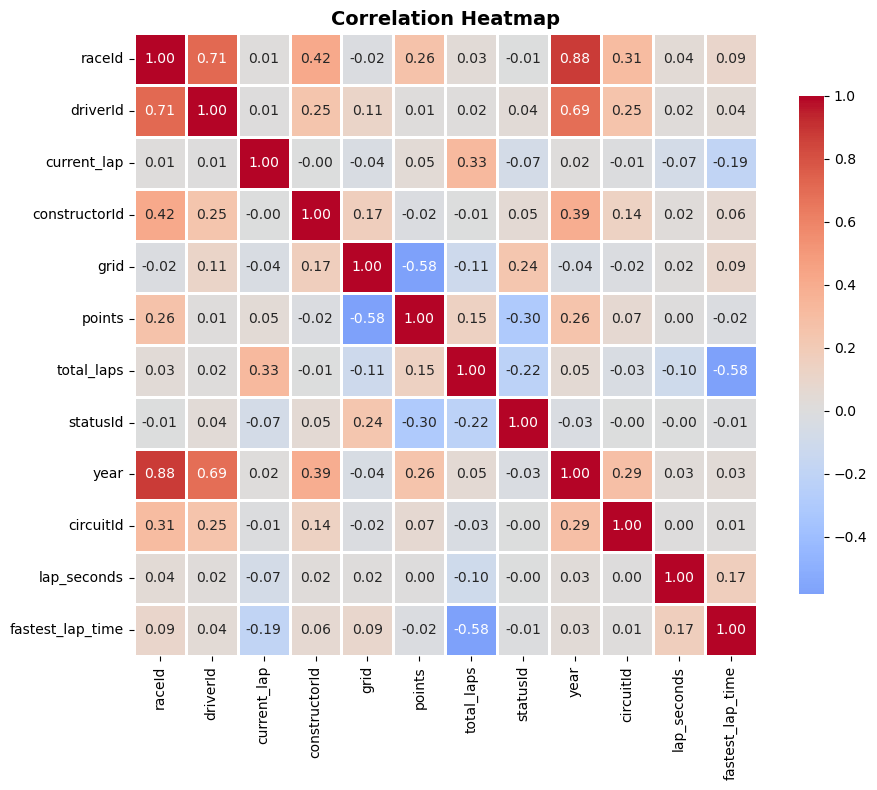

In [68]:
numerical_cols = merged.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()

plt.figure(figsize=(10, 8))
correlation_matrix = merged[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Because most of our numerical columns are Ids, we have strong correlations that are not very interesting. 
For example, 'raceId', 'driverId' or 'constructorId' are strongly correlated with 'year' because Ids are incremented with time.
We have a strong negative correlation between 'grid' and 'points' which means that a low (better) starting position have a strong impact on the number of points gained (more points for better end position). Same for 'statusId' and 'points' as if you are eliminated you will have less points.
These correlations are interesting but have more impact on the final classment of the race than on the prediction of our target variable.
For our target variable : 'fastest_lap_time' 

TO COMPLETE

# Formalisation of the problem

1. Objective

The goal is to predict the fastest lap time (in seconds) of each driver in each race using historical Formula 1 race data (1996–2020).
This prediction can help analyze performance trends of drivers, constructors, and circuits and predict future performances.

2. Type of Problem

Regression problem (target variable is continuous).

Supervised learning, since we have labeled data (past fastest lap times).

3. Target Variable

fastest_lap_time (continuous) → the fastest lap time per driver in a given race, expressed in seconds.

Computed from milliseconds as the minimum lap time (min(milliseconds/1000)) for each (driverId, raceId).


# Model Selection and Implementation

We will start by using linear regression since its the baseline model to use when we have a target that is a continuous value. But since this model has a some limitations, we will also use Random Forest because it can capture non-linear relationships and handle interactions, something that linear regression can't do.

In [36]:
# Keep only the fastest lap per driver per race
fastest = merged.groupby(["raceId","driverId"]).agg({
    "lap_seconds":"min",
    "grid":"first",
    "constructorId":"first",
    "constructorRef":"first",
    "year":"first",
    "circuitId":"first"
}).reset_index()

# Rename target column
fastest = fastest.rename(columns={"lap_seconds":"fastest_lap_s"})

print(fastest.shape)
fastest.head()


(11041, 8)


,raceId,driverId,fastest_lap_s,grid,constructorId,constructorRef,year,circuitId
0,1,1,89.020,18,1,mclaren,2009,1
1,1,2,88.283,9,2,bmw_sauber,2009,1
2,1,3,87.706,5,3,williams,2009,1
3,1,4,88.712,10,4,renault,2009,1
4,1,6,89.923,11,3,williams,2009,1


For this first implementation we decided to create a seperate DataFrame called fastest that contained onlu the fastest lap per driver per race (it has driver id, race id, constructor id, constructorRef, year and circuit id).
This allows us to test our baseline model quickly
 without having to go through the lap by lap dataset since its long.
We did that in order to know if this model allows to predict fastest laps with good accuracy and to know whether we have to add more data and columns to improve our score.

For the full project we will be adding a fastest lap time column in our main merged dataset called merged that we created before, because this lets us ensure consistency and makes our dataset more flexible

In [43]:


X = fastest[["grid","year","circuitId","constructorRef"]]
y = fastest["fastest_lap_s"]


X = X.dropna()
y = y.loc[X.index]

num_features = ["grid","year"]
cat_features = ["circuitId","constructorRef"]


preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])


linreg_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linreg_model.fit(X_train, y_train)

y_pred = linreg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))


Linear Regression Results:
MAE: 4.277456779130382
RMSE: 10.010113275016655
R²: 0.5513421330059352


What we understand from these results is that , on average the model is off by ~4 seconds when predicting a fastest lap.
Large errors exist (a few predictions are off by 10+ seconds), but RMSE is always bigger because it punishes outliers.
And the model explains about 55% of the variance in fastest lap times.


What we can add as data is the length of the circuit and the number of laps for each circuit as that can influence lap times and performances
Which can help us improve our scores

In [44]:
X = fastest[["grid","year","circuitId","constructorRef"]]
y = fastest["fastest_lap_s"]

X = X.dropna()
y = y.loc[X.index]


num_features = ["grid","year"]
cat_features = ["circuitId","constructorRef"]


preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])


rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Random Forest Results:
MAE: 2.214555633415249
RMSE: 9.875447414460112
R²: 0.5633325049374318


With random forest we have a gain in MAE :On average, Random Forest is about 2 seconds closer to the real fastest lap than Linear Regression.
Outliers (races with extreme conditions or bad data) are still hurting the model.
he model explains ~56% of variance, not a huge jump from 55%.
So adding other data files can help improve our scores.
